#### This code extracts the top ten crypto coins and visualizes the coins based on different metrics from CoinGecko

In [1]:
import requests
import pandas as pd
import plotly.express as px
import numpy as np
import plotly.io as pio

# render static image preview
pio.renderers.default = 'png'

# Coin Gecko simple markert url
url = 'https://api.coingecko.com/api/v3/coins/markets'
params = {
    'vs_currency':'usd',
    'order':'market_cap_desc',
    'per_page':10,
    'page':1,
    'sparkline':'false'
}



print("Fetching data from CoinGecko....")
r = requests.get(url,params=params)

if r.status_code == 200:
    print(f"Success: Status Code is {r.status_code}")
    data = r.json()
    
    df_raw = pd.DataFrame(data)

    column_keeping_mask = ['id','current_price','price_change_percentage_24h','total_supply','market_cap']
     
     # Creating the dataframe by filtering out other columns that we dont want and creating a copy so it doesnt affect the original data
    df = df_raw[column_keeping_mask].copy()

    # Rename columns

    df = df.rename(
        columns={
            'id':'name',
            'current_price': 'current_price',
            'price_change_percentage_24h': '24h_price_change_pct',
            'total_supply': 'total_volume'

        }
    )
    
    df['log_volume'] = np.log10(df['total_volume'])
    

    

    
   
    


    
else:
    print(f"Unable to establish connection. Status Code {r.status_code}")

Fetching data from CoinGecko....
Success: Status Code is 200


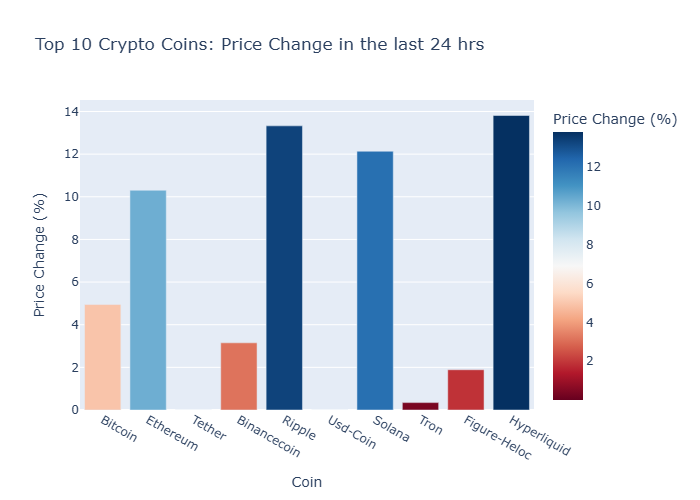

In [2]:
# Visualize coins and their 24 hr price change using Plotly
df['name'] = df['name'].str.title()

fig = px.bar(df,
    x='name',
    y='24h_price_change_pct',
    title='Top 10 Crypto Coins: Price Change in the last 24 hrs',
    labels={'name':'Coin','24h_price_change_pct':'Price Change (%)'},
    color='24h_price_change_pct',
    color_continuous_scale=px.colors.sequential.RdBu
)


fig.write_html("crypto_dashboard.html")

fig.show()

#### Market Concentration Analysis

- How much control do the top 2 or 3 coins have over the entire top 10 crypto ecosystem?

In [3]:
# Calculating the total market cap and volume
total_market_cap = df['market_cap'].sum()
total_trading_volume = df['total_volume'].sum()

# Calculating the percentage share per coin
df['pct_share_market'] = (df['market_cap'] / total_market_cap )* 100



# Sorting the coins 
df_sorted = df.sort_values(by=['pct_share_market'],ascending=False)

# Formatting the data columns
df_sorted['market_cap'] = df['market_cap'].map('${:,.2f}'.format)
df_sorted['pct_share_market'] = df_sorted['pct_share_market'].map('{:,.2f}%'.format)

# Printing the summary stats
print("\n  Market Summary Stats")
print()
print(f"Total Market cap (Top 10): ${total_market_cap:,.2f}")
print(f"Total 24 hr Trading Volume: ${total_trading_volume:,.2f}")

print("\n Market Concentration Per coin")
print(df_sorted[['name','market_cap','pct_share_market']])


  Market Summary Stats

Total Market cap (Top 10): $2,093,422,750,044.00
Total 24 hr Trading Volume: $482,561,659,002.66

 Market Concentration Per coin
           name             market_cap pct_share_market
0       Bitcoin  $1,339,021,276,706.00           63.96%
1      Ethereum    $220,733,516,445.00           10.54%
2        Tether    $186,455,804,869.00            8.91%
3   Binancecoin     $84,010,615,807.00            4.01%
4        Ripple     $79,601,828,135.00            3.80%
5      Usd-Coin     $74,977,667,378.00            3.58%
6        Solana     $43,735,769,275.00            2.09%
7          Tron     $30,311,940,496.00            1.45%
8  Figure-Heloc     $19,448,202,670.00            0.93%
9   Hyperliquid     $15,126,128,263.00            0.72%


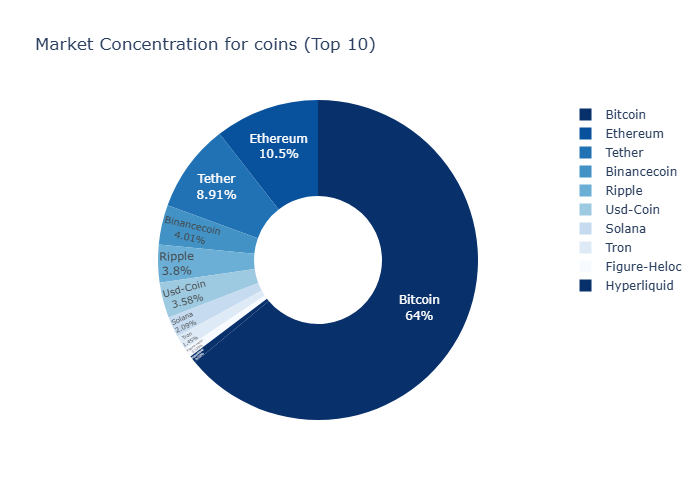

In [4]:
# Visualising the data from analysis

fig = px.pie(df,values='pct_share_market',names='name',title='Market Concentration for coins (Top 10)', color='pct_share_market',
             hole=0.4,
             color_discrete_sequence=px.colors.sequential.Blues_r)


fig.update_traces(textposition='inside', textinfo='percent+label')

fig.show()

fig.write_html("market_share_concentration.html")

#### Market Sentiment

- Is the market having a positive or negative day overall? what's the average move?

In [7]:
df_sorted

# Calcualting number of postive coins
positive_mask = df_sorted['24h_price_change_pct'] > 0

positive_coins = df_sorted[positive_mask]['name'].count() # Can also use positive_coins = positive_mask.sum()
print(f"Total Number of Positive Coins in the last 24 hrs: {positive_coins} coins")
print()

# Calculating number of negative coins
negative_mask = df_sorted['24h_price_change_pct'] < 0

negative_coins = df_sorted[negative_mask]['name'].count()  # Can also use negative_coins = negative_mask.sum()
print(f"Total Number of Negative Coins in the Last 24 hrs: {negative_coins} coins")

# Calculating Average Price change

average_price_change  = df_sorted['24h_price_change_pct'].mean()
median_price_change = df_sorted['24h_price_change_pct'].median()

print()
print(f"Average percentage change of total coins(24 hrs): {average_price_change:,.2f}%")
print()
print(f"Median percentage price change (24 hrs): {median_price_change:,.2f}%")


Total Number of Positive Coins in the last 24 hrs: 10 coins

Total Number of Negative Coins in the Last 24 hrs: 0 coins

Average percentage change of total coins(24 hrs): 5.99%

Median percentage price change (24 hrs): 4.05%


#### High Volume Volatility Tracking

- Are the coins with the highest trading volumes experiencing the biggest price swings today?

In [9]:
# Data sorted by total volume

df_volume_sort = df.sort_values(by=['log_volume'],ascending=False)
print(df_volume_sort.head(10))

print()
print()
print()

# Data sorted by price change in the last 24 hrs
df_price_change_sort = df.sort_values(by=['24h_price_change_pct'], ascending=False)
print(df_price_change_sort.head(10))

           name  current_price  24h_price_change_pct  total_volume  \
2        Tether       0.999499               0.00291  1.920161e+11   
4        Ripple       1.280000              13.32566  9.998565e+10   
7          Tron       0.319643               0.34668  9.483057e+10   
5      Usd-Coin       0.999792               0.00298  7.504888e+10   
8  Figure-Heloc       1.033000               1.88774  1.882122e+10   
9   Hyperliquid      67.990000              13.81131  9.553071e+08   
6        Solana      75.410000              12.13411  6.284330e+08   
3   Binancecoin     622.710000               3.15024  1.347837e+08   
1      Ethereum    1829.730000              10.30430  1.206842e+08   
0       Bitcoin   66813.000000               4.94527  2.004314e+07   

      market_cap  log_volume  pct_share_market  
2   186455804869   11.283338          8.906744  
4    79601828135   10.999938          3.802473  
7    30311940496   10.976948          1.447961  
5    74977667378   10.875344     

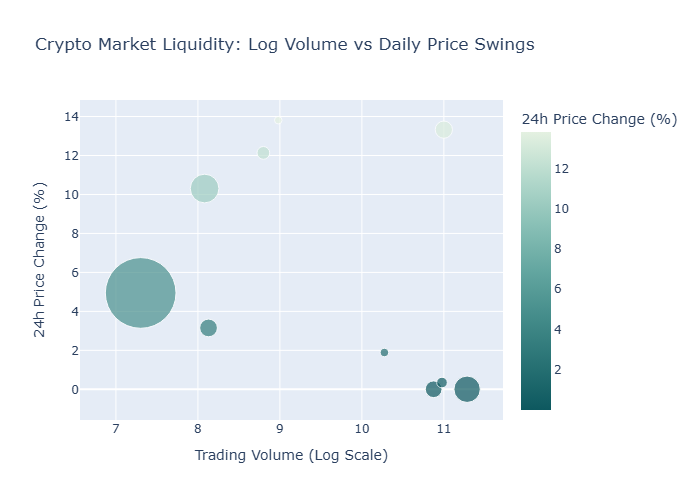

In [10]:
# Visualizing Volume vs Price 

hover_data = ['name','log_volume','24h_price_change_pct','current_price']

fig = px.scatter(
    df,x='log_volume',y='24h_price_change_pct',
    size='pct_share_market',
    hover_data=hover_data,
    color='24h_price_change_pct',
    color_continuous_scale=px.colors.sequential.Mint_r,
    size_max=50,
    title='Crypto Market Liquidity: Log Volume vs Daily Price Swings',
    labels={
        'log_volume': 'Trading Volume (Log Scale)',
        '24h_price_change_pct': '24h Price Change (%)',
        'pct_share_market': 'Market Share Dominance (%)'}
)

fig.show()

fig.write_html('volume_tracking_price.html')